# 一、项目背景

对淘宝用户行为数据进行分析，依照AARRR模型，针对不同层面的问题，探究提升GMV（商品交易总额）的方法。

# 二、数据来源与理解

本项目使用的数据来自阿里云天池平台的“淘宝用户购物行为数据集” (User Behavior Data from Taobao for Recommendation)。
该数据集由阿里巴巴提供，遵循 CC BY-NC-SA 4.0 许可协议。
本项目仅用于非商业学习和研究目的。基于此数据产生的衍生作品同样遵循该许可协议。
数据来源链接：https://tianchi.aliyun.com/dataset/649

本数据集包含了2017年11月25日至2017年12月3日之间，有行为的约一百万随机用户的所有行为

共计5列字段，分别是：userid（用户ID）、itemid（商品ID）、categoryid（商品类目ID）、type（行为类型）和timestamp（时间戳）。

用户行为类型共有四种，分别是：pv、buy、cart和fav。

数据集大小：用户数量987994，商品数量4162024，用户数量987994，商品类目数量9439，所有行为数量100150807。

## 三、导入基本库和读取数据

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
columns = ['user_id','item_id','category_id','behavior','timestamp']
data = pd.read_csv('E:/Taobao/data/UserBehavior.csv',encoding = 'utf-8',names = columns,chunksize = 5000000,header=None,iterator = True)
# 设置中文字体和图表样式
# 确保中文显示正常
plt.rcParams['font.sans-serif'] = ['SimHei', 'WenQuanYi Micro Hei', 'Heiti TC', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")
columns = ['user_id','item_id','category_id','behavior','timestamp']
df = data.get_chunk(5000000)

## 四、数据基本信息

In [201]:
df.sample(10)

,user_id,item_id,category_id,behavior,timestamp
2446385,193356,3129234,903809,pv,1511707019
3311593,232175,3411195,154040,pv,1511649075
1741453,162445,2528832,1379146,pv,1512192104
309155,1013943,5057096,1299190,cart,1512044465
1518638,152224,2294847,2033408,pv,1512052129
3276851,230655,1544080,4022701,buy,1511696275
3602691,24520,1201962,903809,pv,1512313438
1451840,149126,1966287,4145813,pv,1511739715
1130283,134458,4192813,1297791,pv,1511854927
2306330,187655,4076873,411153,pv,1512039725


In [202]:
print("\n=== 数据信息摘要 ===")
print(df.info())
print("\n=== 基本统计信息 ===")
print(df.describe())
print("\n=== 唯一值统计 ===")
print(df.nunique())


=== 数据信息摘要 ===
<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 5 columns):
 #   Column       Dtype
---  ------       -----
 0   user_id      int64
 1   item_id      int64
 2   category_id  int64
 3   behavior     str  
 4   timestamp    int64
dtypes: int64(4), str(1)
memory usage: 190.7 MB
None

=== 基本统计信息 ===
            user_id       item_id   category_id     timestamp
count  5.000000e+06  5.000000e+06  5.000000e+06  5.000000e+06
mean   2.446809e+05  2.579267e+06  2.710101e+06  1.511963e+09
std    2.265588e+05  1.488103e+06  1.464218e+06  8.400232e+05
min    1.000000e+00  3.000000e+00  2.171000e+03  4.401600e+04
25%    1.388410e+05  1.294875e+06  1.349561e+06  1.511763e+09
50%    2.010450e+05  2.578621e+06  2.710853e+06  1.511966e+09
75%    2.637270e+05  3.862411e+06  4.145813e+06  1.512181e+09
max    1.018011e+06  5.163067e+06  5.161669e+06  2.122867e+09

=== 唯一值统计 ===
user_id          48984
item_id        1080623
category_id       7354
beha

# 五、数据清洗


## 1.缺失值检查

In [203]:
missing_values = df.isnull().sum()
print('缺失值统计：',missing_values)
missing_percentage = (missing_values/len(df))*100
print('缺失值占比：',missing_percentage,'%')

缺失值统计： user_id        0
item_id        0
category_id    0
behavior       0
timestamp      0
dtype: int64
缺失值占比： user_id        0.0
item_id        0.0
category_id    0.0
behavior       0.0
timestamp      0.0
dtype: float64 %


## 2. 重复值检查

In [204]:
duplicate_values = df.duplicated().sum()
print('重复值统计：',duplicate_values)
duplicate_percentage = (duplicate_values/len(df))*100
print('重复值占比：',duplicate_percentage,'%')

重复值统计： 5
重复值占比： 9.999999999999999e-05 %


## 3.将时间戳转换为datetime格式

In [205]:
from datetime import datetime,timedelta
df['time'] = pd.to_datetime(df['timestamp'], unit='s') + timedelta(hours=8)


In [206]:
#剔除不在日期范围（2017年11月25日至2017年12月3日之间）内的数据
df = df[(df['time'].between('2017-11-25 00:00:00','2017-12-03 23:59:59'))]
df.drop(columns = ['timestamp'], inplace = True)


In [207]:
df['date'] = df['time'].dt.date
df['hour'] = df['time'].dt.hour
df['weekday'] = df['time'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

In [208]:
df.head()

,user_id,item_id,category_id,behavior,time,date,hour,weekday,is_weekend
0,1,2268318,2520377,pv,2017-11-25 01:21:10,2017-11-25,1,5,1
1,1,2333346,2520771,pv,2017-11-25 06:15:33,2017-11-25,6,5,1
2,1,2576651,149192,pv,2017-11-25 09:21:25,2017-11-25,9,5,1
3,1,3830808,4181361,pv,2017-11-25 15:04:53,2017-11-25,15,5,1
4,1,4365585,2520377,pv,2017-11-25 15:49:06,2017-11-25,15,5,1


## 4.检查异常行为

In [209]:
behavior_counts = df['behavior'].value_counts()
print(behavior_counts)
print(df.nunique())

behavior
pv      4472600
cart     279512
fav      145125
buy      100131
Name: count, dtype: int64
user_id          48984
item_id        1080286
category_id       7352
behavior             4
time            717243
date                 9
hour                24
weekday              7
is_weekend           2
dtype: int64


In [210]:
df.info()

<class 'pandas.DataFrame'>
Index: 4997368 entries, 0 to 4999999
Data columns (total 9 columns):
 #   Column       Dtype         
---  ------       -----         
 0   user_id      int64         
 1   item_id      int64         
 2   category_id  int64         
 3   behavior     str           
 4   time         datetime64[us]
 5   date         object        
 6   hour         int32         
 7   weekday      int32         
 8   is_weekend   int64         
dtypes: datetime64[us](1), int32(2), int64(4), object(1), str(1)
memory usage: 343.1+ MB


本次用于数据分析的数据为:

用户数量：48984

商品数量：1080286

商品类目数量：7352

用户行为数量：4997368

# 六、数据分析和可视化

## 1.AARRR模型


用户每日行为

In [211]:
#buy
daily_buy = df[df['behavior'] == 'buy'].groupby('date').size()
#pv
daily_pv = df[df['behavior'] == 'pv'].groupby('date').size()
#cart
daily_cart = df[df['behavior'] == 'cart'].groupby('date').size()
#fav
daily_fav = df[df['behavior'] == 'fav'].groupby('date').size()


In [212]:
# 计算每日行为占比
# 合并每日各行为数据
behavior_daily = pd.DataFrame({
    'pv': daily_pv,
    'cart': daily_cart,
    'fav': daily_fav,
    'buy': daily_buy
}).fillna(0)

# 计算每日总行为数
behavior_daily['total'] = behavior_daily.sum(axis=1)

# 计算每日各行为占比（保留两位小数）
behavior_daily['浏览占比(%)'] = (behavior_daily['pv'] / behavior_daily['total'] * 100).round(2)
behavior_daily['购物车占比(%)'] = (behavior_daily['cart'] / behavior_daily['total'] * 100).round(2)
behavior_daily['收藏占比(%)'] = (behavior_daily['fav'] / behavior_daily['total'] * 100).round(2)
behavior_daily['购买占比(%)'] = (behavior_daily['buy'] / behavior_daily['total'] * 100).round(2)

# 只保留占比列
daily_behavior = behavior_daily[['浏览占比(%)', '购物车占比(%)', '收藏占比(%)', '购买占比(%)']]
daily_behavior


,浏览占比(%),购物车占比(%),收藏占比(%),购买占比(%)
date,,,,
2017-11-25,89.73,5.45,2.89,1.92
2017-11-26,89.58,5.56,2.96,1.90
2017-11-27,89.36,5.51,2.91,2.22
2017-11-28,89.41,5.50,2.94,2.14
2017-11-29,89.44,5.46,2.91,2.18
2017-11-30,89.65,5.42,2.83,2.11
2017-12-01,89.44,5.78,2.85,1.93
2017-12-02,89.46,5.79,2.90,1.85
2017-12-03,89.45,5.74,2.93,1.88


这么看来每日各行为占比都基本一致，无太大波动

（1）获客，DAU

In [213]:
# 计算每日各行为数据
daily_behavior = df.groupby(['date', 'is_weekend', 'behavior']).size().unstack()
# 提取日期作为 x 轴
dates = [idx[0] for idx in daily_behavior.index]
daily_behavior_df = daily_behavior.reset_index()
daily_behavior_df.to_excel('E:/Taobao/data/日周趋势数据.xlsx', index=False)
daily_behavior
# 按日期和是否周末分组，统计每个行为的独立用户数
daily_dau = df.groupby(['date', 'is_weekend', 'behavior'])['user_id'].nunique().unstack()

In [214]:

# 计算周末和工作日的平均DAU
weekend_dau = daily_dau.loc[daily_dau.index.get_level_values('is_weekend') == 1].mean()
weekday_dau = daily_dau.loc[daily_dau.index.get_level_values('is_weekend') == 0].mean()

# 计算提升百分比
improvement = ((weekend_dau - weekday_dau) / weekday_dau * 100).round(2)

# 创建结果表格
result = pd.DataFrame({
    '工作日平均DAU': weekday_dau.round(2),
    '周末平均DAU': weekend_dau.round(2),
    '提升百分比(%)': improvement
})
result.to_excel('E:/Taobao/data/周末vs工作日DAU提升数据.xlsx', index=True)
print("周末相较于工作日各行为DAU提升情况：")
print(result)

周末相较于工作日各行为DAU提升情况：
          工作日平均DAU   周末平均DAU  提升百分比(%)
behavior                              
buy         7121.8   7606.75      6.81
cart       12292.4  14369.00     16.89
fav         5851.6   6735.50     15.11
pv         34762.8  40355.00     16.09


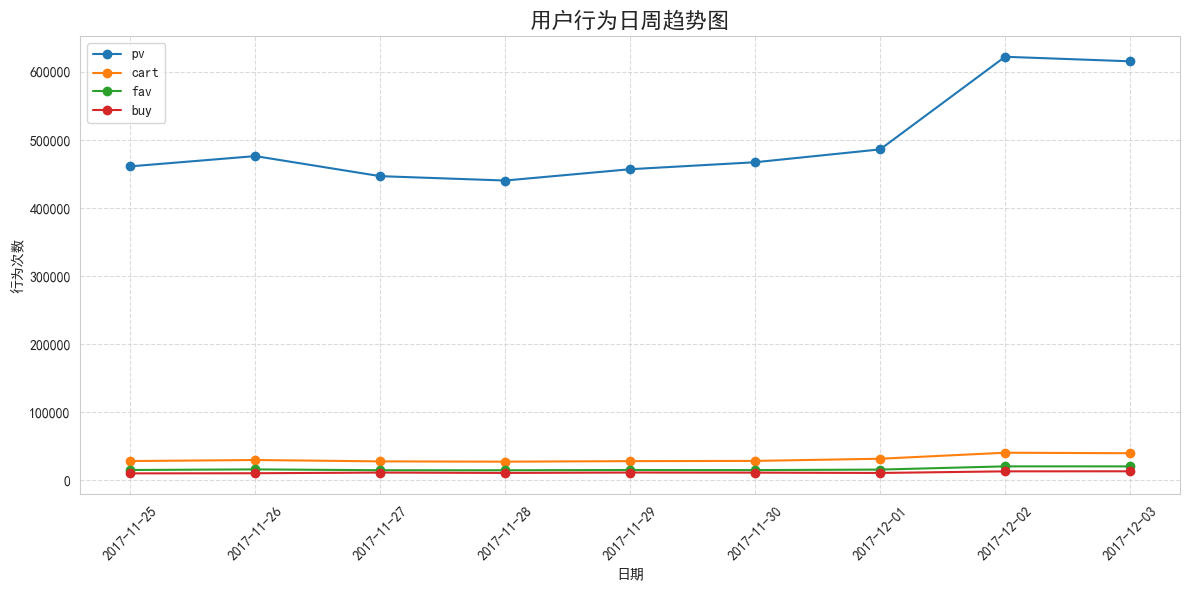

In [215]:
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制日周趋势图
plt.figure(figsize=(12, 6))

for behavior in ['pv', 'cart', 'fav', 'buy']:
    plt.plot(dates, daily_behavior[behavior], marker='o', label=behavior)

plt.title('用户行为日周趋势图', fontsize=16)
plt.xlabel('日期')
plt.ylabel('行为次数')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

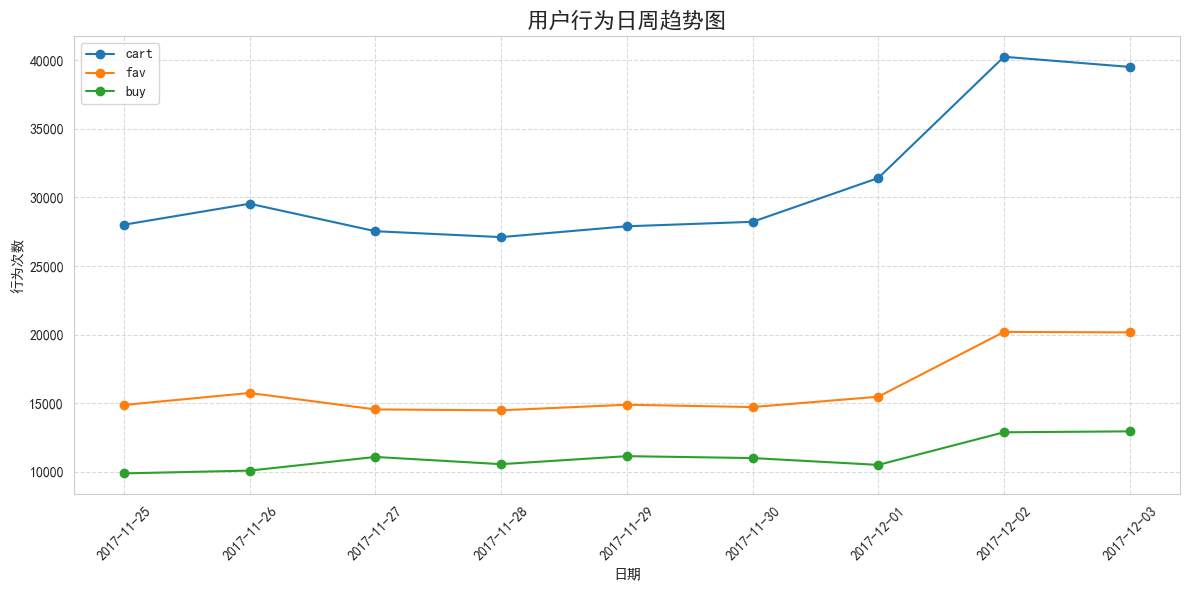

In [216]:
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制日周趋势图(剔除浏览)
plt.figure(figsize=(12, 6))

for behavior in ['cart', 'fav', 'buy']:
    plt.plot(dates, daily_behavior[behavior], marker='o', label=behavior)

plt.title('用户行为日周趋势图', fontsize=16)
plt.xlabel('日期')
plt.ylabel('行为次数')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [217]:
# 计算每小时各行为数据
hourly_behavior = df.groupby(['hour', 'behavior']).size().unstack()
hourly_behavior_df = hourly_behavior.reset_index()
hourly_behavior_df.to_excel('E:/Taobao/data/24小时行为趋势数据.xlsx', index=False)
hourly_behavior

behavior,buy,cart,fav,pv
hour,,,,
0,2916,9181,5070,149884
1,1101,4164,2295,68467
2,603,2150,1403,37536
3,302,1664,911,26422
4,328,1410,797,22544
5,380,1992,919,28039
6,922,3967,2169,60113
7,1845,7486,3843,111536
8,3186,9906,5409,154485


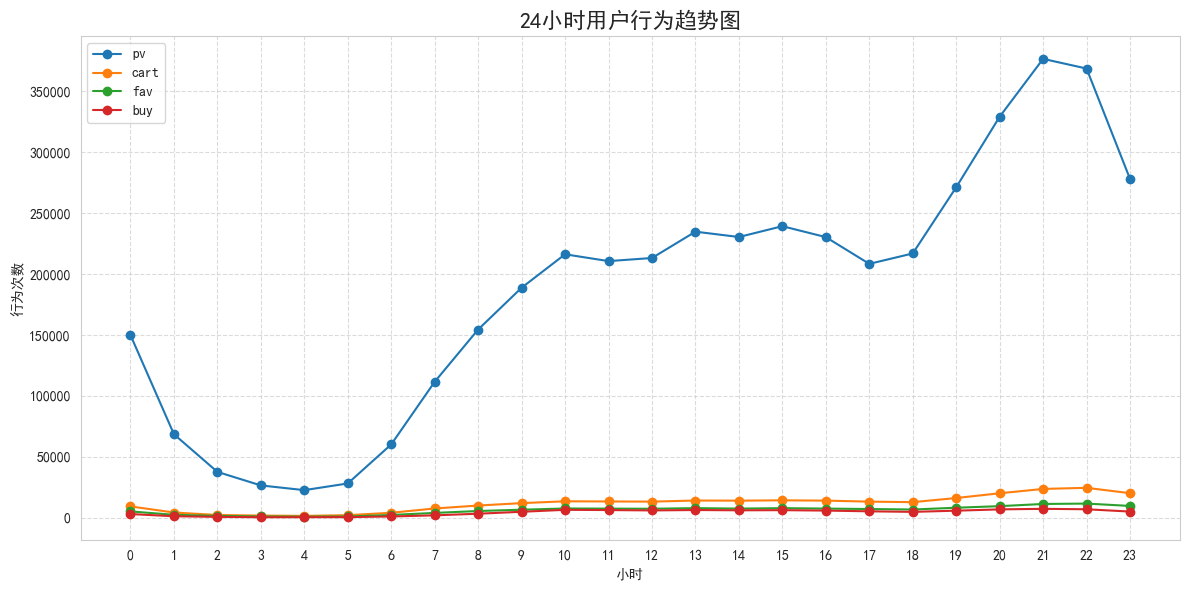

In [218]:
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制24小时行为折线图
plt.figure(figsize=(12, 6))

for behavior in ['pv', 'cart', 'fav', 'buy']:
    plt.plot(hourly_behavior.index, hourly_behavior[behavior], marker='o', label=behavior)

plt.title('24小时用户行为趋势图', fontsize=16)
plt.xlabel('小时')
plt.ylabel('行为次数')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

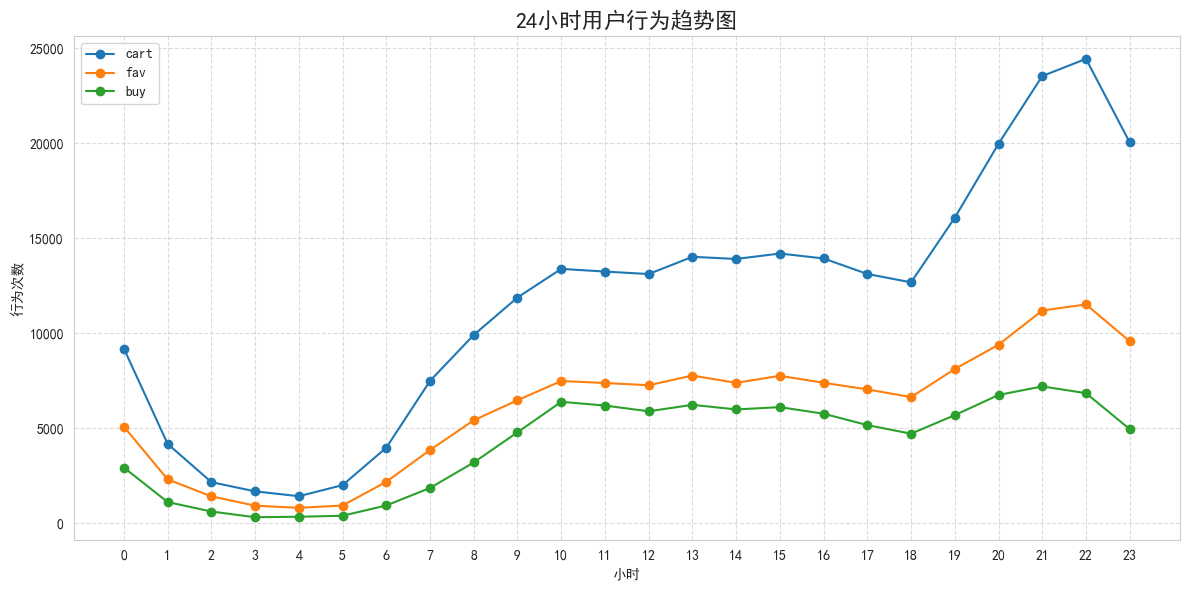

In [219]:
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制24小时行为折线图
plt.figure(figsize=(12, 6))

for behavior in ['cart', 'fav', 'buy']:
    plt.plot(hourly_behavior.index, hourly_behavior[behavior], marker='o', label=behavior)

plt.title('24小时用户行为趋势图', fontsize=16)
plt.xlabel('小时')
plt.ylabel('行为次数')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

根据用户行为日周趋势图，可以看到：
- 周末用户行为量大于平日，说明用户在周末更愿意进行购物。
- 而11月25、26日比12月01、02日用户行为量小，说明月初用户更愿意进行购物。

根据24小时用户行为趋势图，可以看到：

1. 用户活跃的"双峰"与"单峰"模式

- 凌晨小高峰（0-1点）：图1显示cart在凌晨有接近1万次的小高峰

  解读：可能是"睡前经济"或跨日促销活动的体现

  用户画像：夜猫子用户群体，决策相对冲动

- 晚间主高峰（21-22点）：所有行为在此时段达到峰值

  cart峰值：24k+

  pv峰值：350k+

  解读：下班后的"黄金购物时段"，用户有充足时间浏览决策

  业务意义：这是全天最重要的营销和运营窗口

2. 低谷时段的机遇分析

- 凌晨低谷（4-6点）：所有行为均处于最低水平

  传统认知：这是无效时段

  创新视角：可能是跨境购物的黄金窗口（时区差异），或是设置"晨间专属优惠"的蓝海时段

  日间平稳期（10-18点）：buy行为保持稳定

  解读：可能是办公时段的"碎片化购物"，适合推送高决策效率的标准品

（2）激活，浏览行为大于三次的用户算激活

In [220]:
# 计算每天每个用户的浏览次数
daily_pv_per_user = df[df['behavior'] == 'pv'].groupby(['date', 'user_id']).size().reset_index(name='pv_count')

# 筛选出激活用户（浏览次数 > 3）
active_users = daily_pv_per_user[daily_pv_per_user['pv_count'] > 3]

# 统计每天激活的用户数量
daily_active_users = active_users.groupby('date').size().reset_index(name='active_user_count')

# 计算激活率（激活用户数 / 当天总浏览用户数）
daily_total_pv_users = df[df['behavior'] == 'pv'].groupby('date')['user_id'].nunique().reset_index(name='total_pv_users')
daily_active_analysis = daily_active_users.merge(daily_total_pv_users, on='date')
daily_active_analysis['activation_rate(%)'] = (daily_active_analysis['active_user_count'] / daily_active_analysis['total_pv_users'] * 100).round(2)

daily_active_analysis

,date,active_user_count,total_pv_users,activation_rate(%)
0,2017-11-25,23856,33887,70.40
1,2017-11-26,24646,34507,71.42
2,2017-11-27,24025,34077,70.50
3,2017-11-28,23939,34136,70.13
4,2017-11-29,24651,34702,71.04
5,2017-11-30,25070,35305,71.01
6,2017-12-01,25462,35594,71.53
7,2017-12-02,32349,46588,69.44
8,2017-12-03,32111,46438,69.15


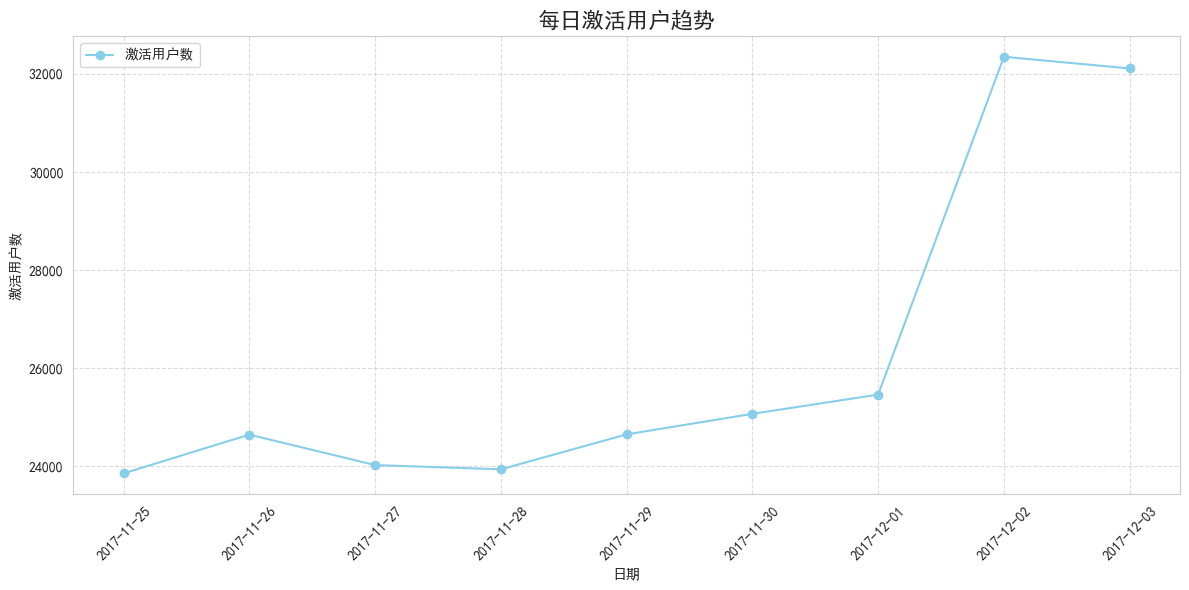

In [221]:
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 可视化激活用户趋势
plt.figure(figsize=(12, 6))
plt.plot(daily_active_analysis['date'], daily_active_analysis['active_user_count'], marker='o', color='skyblue', label='激活用户数')
plt.title('每日激活用户趋势', fontsize=16)
plt.xlabel('日期')
plt.ylabel('激活用户数')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

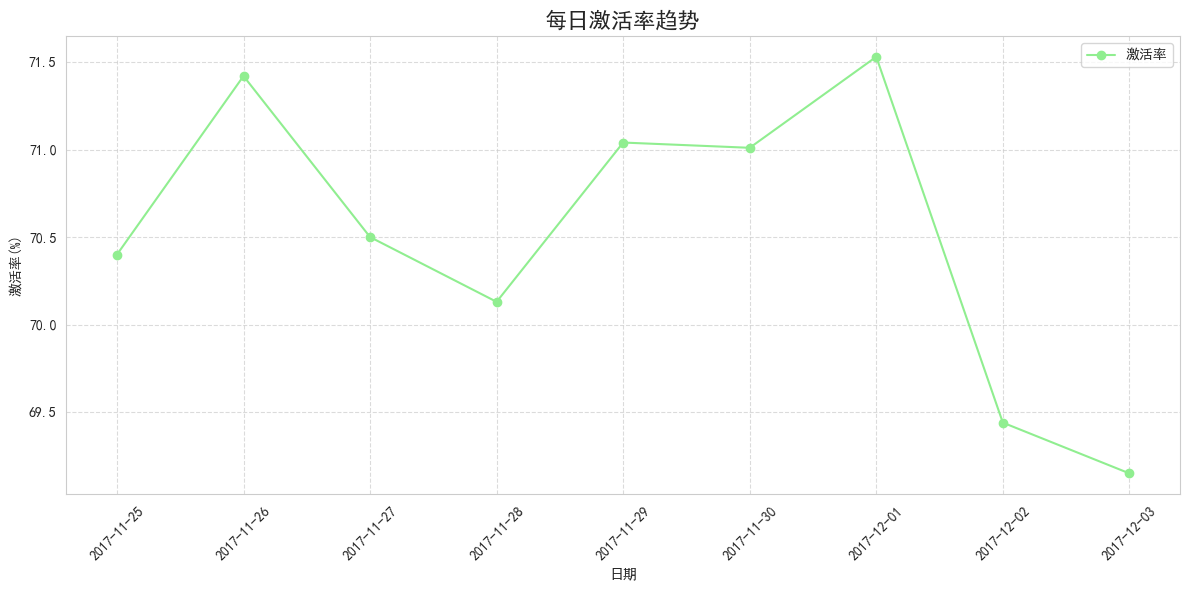

In [222]:
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 可视化激活率趋势
plt.figure(figsize=(12, 6))
plt.plot(daily_active_analysis['date'], daily_active_analysis['activation_rate(%)'], marker='o', color='lightgreen', label='激活率')
plt.title('每日激活率趋势', fontsize=16)
plt.xlabel('日期')
plt.ylabel('激活率(%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

稳步上升期（11月25日 - 12月1日）
- 激活用户数：呈现出非常健康的阶梯式上升趋势。从23,856人稳步增长到25,462人，表明产品的用户基数在不断扩大，且能够持续吸引新用户进行深度浏览。
- 激活率：在70.0% - 71.5%的高位区间波动。其中，11月26日和12月1日是两个峰值（71.42% 和 71.53%）。这说明在这两个时间点，产品的吸引力或引导机制非常有效，成功地将更高比例的访客转化为了“激活用户”。

剧烈下跌期（12月2日 - 12月3日）
- 激活率骤降：从12月1日的 71.53% 断崖式下跌至12月2日的 69.44%，并在12月3日进一步跌至 69.15%。
- 激活用户数逆势上涨：尽管激活率在下降，但激活用户数在12月2日却出现了爆发式增长，达到了32,349人（这是整个统计周期内的最高值），12月3日也维持在32,111人的高位。

在12月2日和3日，总浏览用户数（total_pv_users）激增到了46,000+的量级（对比之前的34,000-35,000）。

这通常意味着进行了大规模的广告投放、渠道推广或公关活动，带来了海量的新流量，或是假期用户人数激增。

问题在于：这些新流量可能质量不高，或者来源广泛且杂乱。例如，通过硬广吸引来的用户可能只是好奇点击，但对产品核心功能（需要浏览3次才能体验）缺乏兴趣，导致他们只看了一眼就离开了。虽然总人数多了，但“打酱油”的人比例变高了，从而拉低了整体的激活率。

建议：

复盘12月2日的流量来源： 检查当天的推广渠道。如果是某个特定渠道（如低质信息流广告）带来的流量，建议调整预算分配，向高转化率的渠道倾斜。

优化“爆款”引导策略： 面对大流量涌入时，需要更短、更直接的路径引导用户完成“三次浏览”。如果流量是精准的，但引导没跟上，需要优化用户引导或页面跳转逻辑。

（3）留存，用户次日留存率

In [223]:
# 定义活跃用户：有任何行为的用户
daily_active_users = df.groupby('date')['user_id'].nunique().reset_index(name='active_users')

# 计算每天的用户ID集合
daily_users = df.groupby('date')['user_id'].unique().reset_index(name='user_ids')

# 计算次日留存率
retention_data = []

# 按日期排序
daily_users = daily_users.sort_values('date')
dates = daily_users['date'].tolist()

for i in range(len(dates) - 1):
    current_date = dates[i]
    next_date = dates[i + 1]

    # 当天活跃用户
    current_users = set(daily_users.loc[daily_users['date'] == current_date, 'user_ids'].iloc[0])
    # 次日活跃用户
    next_users = set(daily_users.loc[daily_users['date'] == next_date, 'user_ids'].iloc[0])

    # 留存用户（当天活跃且次日也活跃）
    retained_users = current_users.intersection(next_users)

    # 计算留存率
    if len(current_users) > 0:
        retention_rate = (len(retained_users) / len(current_users)) * 100
    else:
        retention_rate = 0

    retention_data.append({
        'date': current_date,
        'next_date': next_date,
        'current_active_users': len(current_users),
        'retained_users': len(retained_users),
        'retention_rate(%)': round(retention_rate, 2)
    })

retention_df = pd.DataFrame(retention_data)
retention_df

,date,next_date,current_active_users,retained_users,retention_rate(%)
0,2017-11-25,2017-11-26,34903,27497,78.78
1,2017-11-26,2017-11-27,35466,27518,77.59
2,2017-11-27,2017-11-28,35138,27556,78.42
3,2017-11-28,2017-11-29,35216,27864,79.12
4,2017-11-29,2017-11-30,35768,28539,79.79
5,2017-11-30,2017-12-01,36416,28981,79.58
6,2017-12-01,2017-12-02,36719,36064,98.22
7,2017-12-02,2017-12-03,48092,47140,98.02


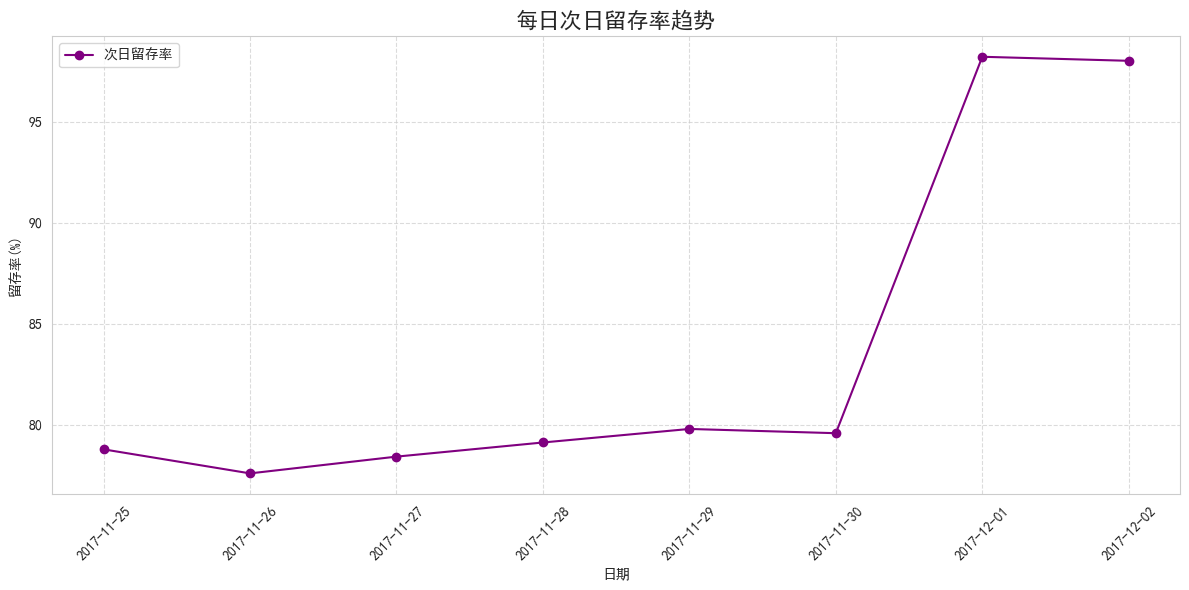

In [224]:
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 可视化留存率趋势
plt.figure(figsize=(12, 6))
plt.plot(retention_df['date'], retention_df['retention_rate(%)'], marker='o', color='purple', label='次日留存率')
plt.title('每日次日留存率趋势', fontsize=16)
plt.xlabel('日期')
plt.ylabel('留存率(%)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

用户习惯： 用户倾向于在周末集中进行购物和浏览活动。

运营启示：

- 营销节奏： 既然周末是流量和留存的高峰，运营活动（如新品发布、优惠券发放、直播带货）应重点安排在周五晚上或周六，以最大化利用用户的高活跃度。
- 指标解读： 在评估产品健康度时，需要将工作日和周末的数据分开看。如果仅看12月2日的数据，可能会误判产品取得了巨大突破；但如果结合周末效应，这其实是符合预期的自然增长。
- 预测模型： 在进行用户增长预测时，必须将“星期几”作为一个重要变量纳入模型，否则预测结果会有较大偏差。

（3）收入，用转化漏斗代替

In [225]:
# 计算各行为总数量
total_buy = daily_buy.sum()
total_pv = daily_pv.sum()
total_cart = daily_cart.sum()
total_fav = daily_fav.sum()

In [226]:
behavior_data = pd.DataFrame({
    '行为类型': ['浏览(pv)', '加入购物车(cart)', '收藏(fav)', '购买(buy)'],
    '数量': [total_pv, total_cart, total_fav, total_buy],
    '占比(%)': [(total_pv/df.shape[0])*100, (total_cart/df.shape[0])*100,
               (total_fav/df.shape[0])*100, (total_buy/df.shape[0])*100]
})
behavior_data.to_excel('E:/Taobao/data/用户行为占比数据.xlsx', index=False)

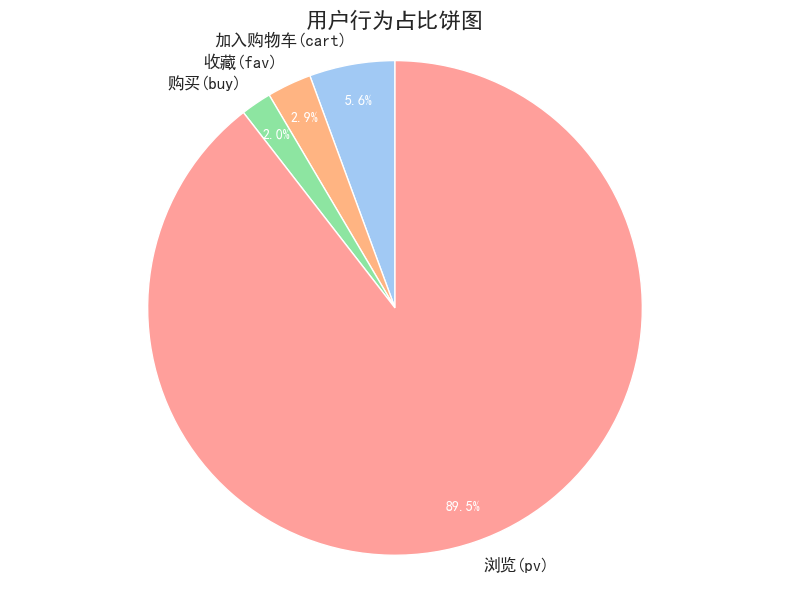

In [227]:

# 确保中文显示正常
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 准备饼图数据
behavior_data = [total_cart,total_fav, total_buy,total_pv]
behavior_labels = [ '加入购物车(cart)', '收藏(fav)', '购买(buy)','浏览(pv)']
behavior_colors = sns.color_palette('pastel')[0:4]

# 绘制饼图 - 解决文字重叠问题
plt.figure(figsize=(8, 6))  # 增大图表尺寸

# 绘制饼图，调整标签距离和百分比显示
wedges, texts, autotexts = plt.pie(
    behavior_data,
    labels=behavior_labels,
    colors=behavior_colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    labeldistance=1.1,  # 增加标签距离
    pctdistance=0.85,   # 调整百分比位置
    radius=0.8          # 调整饼图半径
)

# 调整文字大小和颜色
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')

plt.title('用户行为占比饼图', fontsize=16)
plt.axis('equal')  # 确保饼图是圆形
plt.tight_layout()
plt.show()

饼图显示用户各行为占比情况

In [228]:
#统计各阶段用户数
# 浏览用户数
pv_users = df[df['behavior'] == 'pv']['user_id'].nunique()

#收藏/加购用户数
fav_cart_users = df[
    (df['behavior'].isin(['fav', 'cart'])) &
    (df['user_id'].isin(df[df['behavior'] == 'pv']['user_id']))
]['user_id'].nunique()

#购买用户数
buy_users = df[
    (df['behavior'] == 'buy') &
    (df['user_id'].isin(df[df['behavior'].isin(['fav', 'cart'])]['user_id'])) &
    (df['user_id'].isin(df[df['behavior'] == 'pv']['user_id']))
]['user_id'].nunique()

#计算转化率
pv_to_favcart_rate = (fav_cart_users / pv_users) * 100 if pv_users > 0 else 0
favcart_to_buy_rate = (buy_users / fav_cart_users) * 100 if fav_cart_users > 0 else 0

print("=== 转化漏斗分析 ===")
print(f"浏览用户数: {pv_users}")
print(f"收藏/加购用户数: {fav_cart_users}")
print(f"购买用户数: {buy_users}")
print(f"pv → fav/cart 转化率: {pv_to_favcart_rate:.2f}%")
print(f"fav/cart → buy 转化率: {favcart_to_buy_rate:.2f}%")
print(f"购买用户占比{(buy_users/pv_users * 100):.2f}%")

# 准备数据
funnel_data = [pv_users, fav_cart_users, buy_users]
funnel_labels = ['浏览(pv)', '收藏/加购(fav/cart)', '购买(buy)']

=== 转化漏斗分析 ===
浏览用户数: 48782
收藏/加购用户数: 42631
购买用户数: 29848
pv → fav/cart 转化率: 87.39%
fav/cart → buy 转化率: 70.01%
购买用户占比61.19%


In [229]:
conversion_funnel = pd.DataFrame({
    '阶段': ['浏览(PV)', '收藏/加购', '购买(Buy)'],
    '人数': [pv_users, fav_cart_users, buy_users],
    '转化率(%)': [100, pv_to_favcart_rate, favcart_to_buy_rate]
})
conversion_funnel.to_excel('E:/Taobao/data/转化漏斗数据.xlsx', index=False)

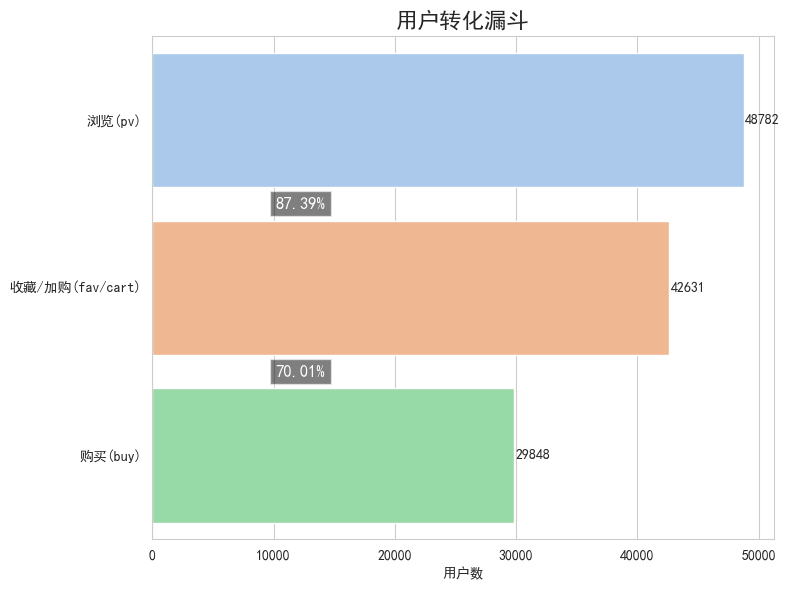

In [230]:
# 确保中文显示正常
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# 绘制漏斗图（使用水平条形图模拟）
plt.figure(figsize=(8, 6))
# 解决Seaborn警告
ax = sns.barplot(x=funnel_data, y=funnel_labels, hue=funnel_labels, palette='pastel', legend=False)

# 添加数值标签
for i, value in enumerate(funnel_data):
    plt.text(value + 100, i, f'{value}', va='center')

# 添加转化率标签 - 确保百分比对齐
align_x = max(funnel_data) * 0.25  # 统一在条形图的25%宽度位置

# 第一个转化率标签（pv到fav/cart）
plt.text(align_x, 0.5, f'{pv_to_favcart_rate:.2f}%',
         ha='center', va='center', color='white', fontsize=12,
         bbox=dict(facecolor='black', alpha=0.5))

# 第二个转化率标签（fav/cart到buy）
plt.text(align_x, 1.5, f'{favcart_to_buy_rate:.2f}%',
         ha='center', va='center', color='white', fontsize=12,
         bbox=dict(facecolor='black', alpha=0.5))

plt.title('用户转化漏斗', fontsize=16)
plt.xlabel('用户数')
plt.tight_layout()
plt.show()

In [231]:
# 统计各种行为的数量
behavior_counts = df['behavior'].value_counts()
behavior_counts

behavior
pv      4472600
cart     279512
fav      145125
buy      100131
Name: count, dtype: int64

In [232]:
# 创建转化漏斗数据
pv_count = behavior_counts.get('pv', 0)
cart_count = behavior_counts.get('cart', 0)
fav_count = behavior_counts.get('fav', 0)
buy_count = behavior_counts.get('buy', 0)
cart_fav_total = cart_count + fav_count
# 浏览到购买转化率
pv_to_buy_rate = (buy_count / pv_count) * 100 if pv_count > 0 else 0
print(f"\n浏览到购买转化率: {pv_to_buy_rate:.4f}%")
# 浏览到收藏/加购转化率
pv_to_cart_fav_rate = (cart_fav_total / pv_count) * 100 if cart_fav_total > 0 else 0
print(f"浏览到收藏/加购转化率: {pv_to_cart_fav_rate:.4f}%")
# 加购/收藏到购买转化率（合并计算）
cart_fav_to_buy_rate = (buy_count / cart_fav_total) * 100 if cart_fav_total > 0 else 0
print(f"加购/收藏到购买转化率: {cart_fav_to_buy_rate:.4f}%")


浏览到购买转化率: 2.2388%
浏览到收藏/加购转化率: 9.4942%
加购/收藏到购买转化率: 23.5804%


In [233]:
# 构建转化漏斗DataFrame
conversion_funnel = pd.DataFrame({
    '阶段': ['浏览(PV)', '加购/收藏', '购买(Buy)'],
    '人数': [pv_count, cart_fav_total, buy_count],
    '转化率(%)': [100,pv_to_cart_fav_rate, pv_to_buy_rate]
})
conversion_funnel.to_excel("E:/Taobao/淘宝用户转化漏斗.xlsx")

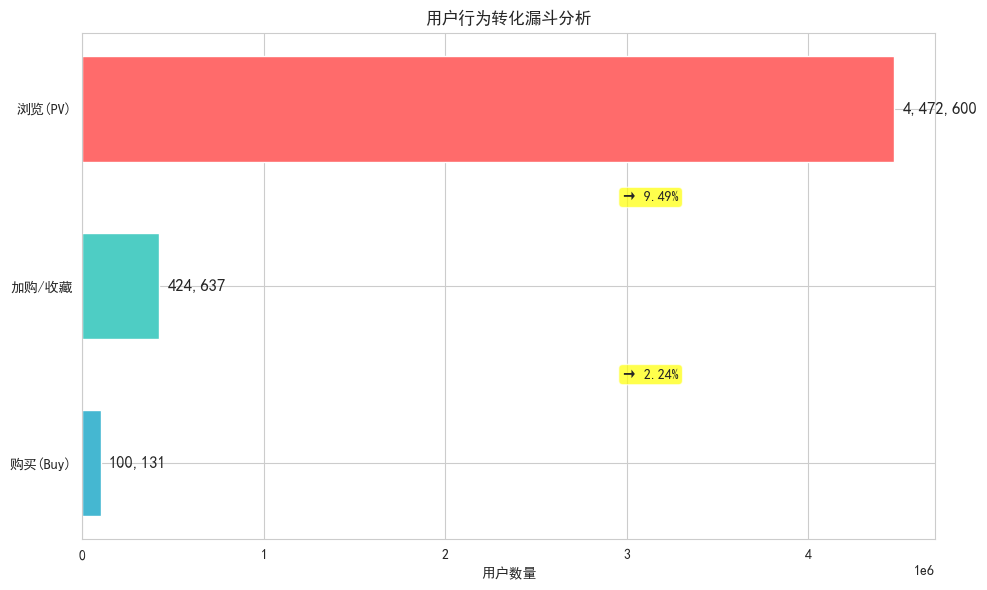

In [234]:
# 确保中文显示正常
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False# 使用matplotlib绘制转化漏斗图
plt.figure(figsize=(10, 6))

# 定义颜色
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# 创建漏斗图
stages = conversion_funnel['阶段']
values = conversion_funnel['人数']
bars = plt.barh(range(len(stages)), values, color=colors, height=0.6)

# 在每个条形上显示数值
for i, v in enumerate(values):
    plt.text(v + max(values) * 0.01, i, f'{v:,}', va='center', fontsize=12)

# 显示转化率
for i in range(len(values)-1):
    rate = conversion_funnel.iloc[i+1]['转化率(%)']
    plt.text(max(values) * 0.7, i+0.5, f'→ {rate:.2f}%', va='center', ha='center',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7), fontsize=10)

plt.xlabel('用户数量')
plt.title('用户行为转化漏斗分析')
plt.yticks(range(len(stages)), stages)
plt.gca().invert_yaxis()  # 倒置y轴，使最上面是第一阶段
plt.tight_layout()
plt.show()

### 分析

行为占比分析：

- 从用户行为占比饼图可以看出，浏览行为(pv)占比最高(89.5%)，购买行为(buy)仅占2.0%，加购物车(cart)和收藏(fav)分别占5.6%和2.9%。

用户转化漏斗分析：

- 浏览用户到收藏/加购的转化率为87.39%，说明大多数用户在浏览后对商品有兴趣

- 收藏/加购到购买的转化率为70.01%，表明有购买意向的用户中大部分最终完成了购买

- 最终购买用户占总浏览用户的61.19%，显示用户整体消费意愿较强

用户行为转化漏斗分析：

- 浏览行为到收藏/加购的转化率为9.49%，浏览到购买的转化率为2.24%

问题分析：

- 商品质量问题：部分商品可能存在质量不符合预期的情况，导致用户在收藏/加购后放弃购买

- 价格因素：价格可能是影响购买决策的重要因素，部分用户可能在最后阶段因价格考虑而放弃加购、收藏和购买

- 商品信息不完整：商品详情页信息可能不够全面，导致用户无法确认是否符合自己的需求

- 评论区影响：负面评论可能影响用户的购买信心

建议：
- 进行A/B测试，评估不同商品详情页的转化率
- 对高退货率商品进行重点监控和分析
- 针对收藏/加购用户推出个性化优惠
- 引导商家提供更全面的商品信息，包括详细参数、使用场景等

### (3).用户价值RFM分析

由于数据没有消费金额信息以及数据集时间间隔较小，只根据消费频率和最近消费时间进行用户价值分层。

In [235]:
# 首先创建用户行为统计
user_behavior = df.groupby('user_id').agg({
    'behavior': lambda x: x.value_counts().to_dict(),
    'date': ['min', 'max']
}).reset_index()


In [236]:
# 重命名列
user_behavior.columns = ['user_id', 'behavior_counts', 'first_date', 'last_date']

In [237]:
# 计算各行为次数
user_behavior['pv_count'] = user_behavior['behavior_counts'].apply(lambda x: x.get('pv', 0))
user_behavior['cart_count'] = user_behavior['behavior_counts'].apply(lambda x: x.get('cart', 0))
user_behavior['fav_count'] = user_behavior['behavior_counts'].apply(lambda x: x.get('fav', 0))
user_behavior['buy_count'] = user_behavior['behavior_counts'].apply(lambda x: x.get('buy', 0))
# 计算总行为次数
user_behavior['total_behavior'] = user_behavior['pv_count'] + user_behavior['cart_count'] + user_behavior['fav_count'] + user_behavior['buy_count']

In [238]:
# 计算R分（最近度）：基于购买日期
# 确定日期范围
min_date = df['date'].min()
max_date = df['date'].max()
date_range = (max_date - min_date).days + 1

# 计算每个用户的最后购买日期
last_buy_date = df[df['behavior'] == 'buy'].groupby('user_id')['date'].max().reset_index()
last_buy_date.columns = ['user_id', 'last_buy_date']

# 合并到用户行为数据
user_behavior = user_behavior.merge(last_buy_date, on='user_id', how='left')

# 计算购买日期距离最后一天的天数
def calculate_r_score(row):
    if pd.isna(row['last_buy_date']):
        return 0
    else:
        days_from_end = (max_date - row['last_buy_date']).days
        # 最近购买的用户分数最高
        if days_from_end == 0:
            return 5
        elif days_from_end <= 2:
            return 4
        elif days_from_end <= 4:
            return 3
        elif days_from_end <= 6:
            return 2
        else:
            return 1

user_behavior['R_score'] = user_behavior.apply(calculate_r_score, axis=1)

In [239]:
# 计算F分（频率）
def calculate_f_score(row):
    if row['buy_count'] >= 3:
        return 5
    elif row['buy_count'] == 2:
        return 4
    elif row['buy_count'] == 1:
        return 3
    elif row['cart_count'] >= 5:
        return 2
    elif row['cart_count'] >= 1 or row['fav_count'] >= 5:
        return 1
    else:
        return 0

user_behavior['F_score'] = user_behavior.apply(calculate_f_score, axis=1)

In [240]:
# 计算RFM总分
user_behavior['RFM_score'] = user_behavior['R_score'] + user_behavior['F_score']

In [241]:
# 基于RFM总分进行用户分层
def segment_user(row):
    r_score = row['R_score']
    f_score = row['F_score']

    # 定义高低标准
    high_r = r_score >= 4
    low_r = r_score < 4
    high_f = f_score >= 4
    low_f = f_score < 4

    # 分类逻辑
    if high_r and high_f:
        return '重要价值客户'
    elif high_r and low_f:
        return '重要发展客户'
    elif low_r and high_f:
        return '一般保持客户'
    else:  # 其他情况（包括低R、低F）
        return '挽留客户'

user_behavior['segment'] = user_behavior.apply(segment_user, axis=1)


In [242]:
# 统计各分层用户数量
segment_counts = user_behavior['segment'].value_counts()
print("\n用户分层统计：")
print(segment_counts)


用户分层统计：
segment
挽留客户      22608
重要价值客户    14627
一般保持客户     7265
重要发展客户     4484
Name: count, dtype: int64


In [243]:
user_behavior.to_excel('E:/Taobao/user_rfm_analysis.xlsx', index=False)

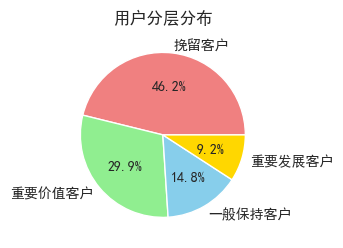

In [244]:
# 确保中文显示正常
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.subplot(2, 2, 4)
segment_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightcoral', 'lightgreen', 'skyblue', 'gold'])
plt.title('用户分层分布')
plt.ylabel('')

plt.tight_layout()
plt.show()

## 分析

问题分析（仅基于2017-11-25至2017-12-03数据）
1. 挽留客户 (46.2%) ——【浏览者/观望者】
- 真实身份：这9天里只看不买的人，或者是加购了但没付款的人。
- 问题所在：为什么这么多人（近一半）看过你的商品却没下单？是价格问题？信任问题？还是流程太复杂？
建议：
- 查看流失节点：分析这部分人的路径，看他们是卡在“加购”环节，还是“结算”环节。
- 定向营销：对这部分人推送“新人专享价”或者“加购优惠券”，刺激第一次下单。
2. 重要价值客户 (29.9%) ——【高活跃购买者】
- 真实身份：这9天内不仅买了，而且可能买了不止一次，或者在多个品类都有购买行为。
- 现状：这是你这9天里最活跃的群体。能在短短9天内就产生复购，说明他们对你的产品非常认可，或者需求非常迫切。
建议：
- 保持粘性：不要过度打扰，但可以推送新品或高客单价商品。
- 收集反馈：这部分人是调研的最佳对象，问问他们为什么买得这么勤。
3. 一般保持客户 (14.8%) ——【高频浏览/低频购买】
- 真实身份：这9天内可能只买了一次，或者只浏览了很少的页面。
- 现状：他们是“路人甲”。可能只是偶然路过，或者需求不大。
建议：
- 唤醒：不需要强推，通过内容营销（如种草文章、短视频）保持品牌在他们脑海中的印象即可。
4. 重要发展客户 (9.2%) ——【近期浏览加购但未购买/低频购买】
- 真实身份：这类人在9天内可能看了很多页面（PV很高），或者加购了很多商品（Cart很高），但实际购买行为（Buy）并不算特别突出（相对于“重要价值客户”）。
- 现状：这是最有价值的潜在客户。他们表现出极强的兴趣（高频浏览），但就是差临门一脚（没买）。
建议：
- 精准拦截：这部分人是“必争之地”。他们可能是价格敏感型，或者在比价。
- 策略：给他们发一张“满减券”或者“限时折扣”，往往能立刻促成转化。

# 2.商品层面

商品类目有7354种，值得分析哪些品类的商品更受用户欢迎。


In [245]:
#已购买商品品类排名
cs = df[df['behavior']=='buy']['category_id'].value_counts().reset_index()
cs.columns = ['category_id', 'item_count']
cs.to_excel('E:/Taobao/data/已购买商品品类排名.xlsx', index=False)
cs

,category_id,item_count
0,1464116,1847
1,2735466,1797
2,4145813,1686
3,2885642,1582
4,4756105,1445
...,...,...
4050,3147601,1
4051,2573032,1
4052,3893658,1
4053,4670238,1


In [246]:
#已浏览商品品类排名
cs_pv = df[df['behavior']=='pv']['category_id'].value_counts().reset_index()
cs_pv.columns = ['category_id', 'item_count']
cs_pv.to_excel('E:/Taobao/data/已浏览商品品类排名.xlsx', index=False)
cs_pv

,category_id,item_count
0,4756105,243731
1,4145813,161196
2,2355072,158186
3,3607361,148226
4,982926,141710
...,...,...
7278,3964605,1
7279,1961203,1
7280,5079277,1
7281,4788932,1


In [247]:
#已加购收藏商品品类排名
cs_cart_fav = df[(df[('behavior')]=='cart') | (df['behavior']=='fav')]['category_id'].value_counts().reset_index()
cs_cart_fav.columns = ['category_id', 'item_count']
cs_cart_fav.to_excel('E:/Taobao/data/已加购收藏商品品类排名.xlsx', index=False)
cs_cart_fav

,category_id,item_count
0,4756105,19511
1,4145813,14788
2,982926,12411
3,2355072,10343
4,4801426,9521
...,...,...
5102,4341842,1
5103,1518771,1
5104,4783904,1
5105,168173,1


一、已购买商品品类排名靠前（核心变现品类）
- 特征：用户实际付款购买最多的品类，直接贡献销售额。
- 策略方向：巩固优势、提升复购、挖掘高价值用户

二、已浏览商品品类排名靠前（高关注度品类）
- 特征：用户兴趣高但未转化，可能是“比价中”或“需求未被满足”。
- 策略方向：精准触达、消除顾虑、促进转化

三、已加购/收藏商品品类排名靠前（高意向品类）
- 特征：用户有明确购买意向，但尚未付款，处于“决策犹豫期”。
- 策略方向：临门一脚、消除障碍、促成交易